# TP2 - Telemetry Data Processing Pipeline
## Bronze to Silver Transformation for Sensor Data

## analyse de base du telemetry.csv

In [17]:
import pandas as pd
datas = pd.read_csv("telemetry.csv")
nb_lignes = datas.shape[0]
nb_colonnes = datas.shape[1]
print("nbre de lignes : ", nb_lignes)
print("nbre de colonnes : ", nb_colonnes)
print("complete dimensions : ", datas.shape)
print("Colonnes")
print(datas.columns)
print("Aperçu des données")
print(datas.head(10))


nbre de lignes :  135626
nbre de colonnes :  7
complete dimensions :  (135626, 7)
Colonnes
Index(['machine_id', 'timestamp', 'temperature_c', 'pressure_bar',
       'voltage_mean_v', 'rotation_mean_rpm', 'pieces_produced'],
      dtype='str')
Aperçu des données
  machine_id            timestamp  temperature_c  pressure_bar  \
0    MACH-01  2025-06-01 00:00:00         46.348       198.203   
1    MACH-01  2025-06-01 00:00:00         46.332       198.206   
2    MACH-01  2025-06-01 01:00:00         48.762       198.295   
3    MACH-01  2025-06-01 02:00:00         51.352       199.545   
4    MACH-01  2025-06-01 03:00:00         49.512       201.641   
5    MACH-01  2025-06-01 04:00:00         51.982       200.157   
6    MACH-01  2025-06-01 05:00:00         50.402       199.914   
7    MACH-01  2025-06-01 06:00:00         49.732       198.551   
8    MACH-01  2025-06-01 07:00:00         50.292       199.972   
9    MACH-01  2025-06-01 08:00:00         48.672       200.262   

   voltage_

In [18]:

# Vérification des NaN dans le bronze
print("NaN par colonne :")
print(datas.isna().sum())
print()
print("Total NaN :", datas.isna().sum().sum())


NaN par colonne :
machine_id             0
timestamp              0
temperature_c        894
pressure_bar         995
voltage_mean_v         0
rotation_mean_rpm    958
pieces_produced        0
dtype: int64

Total NaN : 2847


## Analyse des valeurs manquantes — justification de la stratégie d'imputation

In [19]:
# ── Analyse des valeurs manquantes ────────────────────────────────────────────
# Objectif : comprendre POURQUOI les valeurs manquent avant de choisir
#            une stratégie d'imputation.

nan_cols = ["temperature_c", "pressure_bar", "rotation_mean_rpm"]
datas_sorted = datas.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

# ── 1. Répartition des NaN par machine ────────────────────────────────────────
print("=" * 65)
print("1. RÉPARTITION DES NaN PAR MACHINE")
print("=" * 65)
for col in nan_cols:
    counts = datas_sorted.groupby("machine_id")[col].apply(lambda x: x.isna().sum())
    counts = counts[counts > 0].sort_values(ascending=False)
    print(f"\n{col} :")
    print(counts.to_string())

# ── 2. Pattern temporel : les NaN sont-ils consécutifs ? ──────────────────────
print("\n" + "=" * 65)
print("2. PATTERN TEMPOREL — longueur des gaps consécutifs")
print("=" * 65)
for col in nan_cols:
    s = datas_sorted[col].isna()
    groups = s.ne(s.shift()).cumsum()
    consec_lengths = s.groupby(groups).sum()
    gap_lengths = consec_lengths[consec_lengths > 0]
    print(f"{col:25s} → gaps : {len(gap_lengths):3d}  |  "
          f"max consécutif : {int(gap_lengths.max())}h  |  "
          f"médiane : {gap_lengths.median():.0f}h")

# ── 3. Corrélations entre features ────────────────────────────────────────────
print("\n" + "=" * 65)
print("3. CORRÉLATIONS ENTRE FEATURES (Pearson)")
print("=" * 65)
corr = datas[["temperature_c", "pressure_bar", "voltage_mean_v", "rotation_mean_rpm"]].corr()
print(corr.round(3).to_string())

# ── 4. NaN coïncident-ils avec des arrêts machine ? ───────────────────────────
print("\n" + "=" * 65)
print("4. NaN PENDANT LES ARRÊTS MACHINE (pieces_produced == 0)")
print("=" * 65)
for col in nan_cols:
    total_nan   = datas[col].isna().sum()
    nan_at_stop = datas[(datas["pieces_produced"] == 0) & datas[col].isna()].shape[0]
    pct = nan_at_stop / total_nan * 100 if total_nan > 0 else 0
    print(f"{col:25s} → {nan_at_stop:3d} / {total_nan} NaN pendant arrêt ({pct:.1f} %)")

# ── 5. Conclusion ──────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("5. CONCLUSION — JUSTIFICATION DE L'INTERPOLATION LINÉAIRE")
print("=" * 65)
print("""
Mécanisme de manquement (MAR — Missing At Random conditionnel) :
  • Les NaN sont répartis sur plusieurs machines sans concentration
    anormale → pas de biais systématique par équipement.
  • Les gaps sont courts (médiane ≤ quelques heures) et consécutifs
    → cohérent avec une panne transitoire de capteur.
  • La faible proportion de NaN pendant les arrêts machine confirme
    que le manquement n'est pas structurellement lié à l'état arrêté
    (ce serait alors MNAR et nécessiterait un flag dédié).

Corrélations inter-features :
  • Les corrélations entre variables sont faibles (< 0.3 en général).
  • Un imputation par KNN multi-varié n'apporterait pas de gain
    significatif par rapport à une interpolation temporelle simple.

Données de type série temporelle continue :
  • Les capteurs mesurent des grandeurs physiques qui évoluent
    progressivement dans le temps.
  • L'interpolation linéaire entre deux mesures valides est
    la meilleure approximation disponible pour un gap court.

→ Stratégie retenue : interpolation linéaire par machine,
  groupée par machine_id pour respecter l'indépendance des équipements.
""")

1. RÉPARTITION DES NaN PAR MACHINE

temperature_c :
machine_id
MACH-11    110
MACH-08     76
MACH-02     75
MACH-09     65
MACH-15     63
MACH-05     62
MACH-13     61
MACH-12     58
MACH-14     57
MACH-03     55
MACH-07     51
MACH-04     49
MACH-01     44
MACH-06     43
MACH-10     25

pressure_bar :
machine_id
MACH-09    114
MACH-13    109
MACH-07     92
MACH-10     85
MACH-06     72
MACH-01     66
MACH-12     58
MACH-15     57
MACH-11     56
MACH-05     56
MACH-04     53
MACH-14     53
MACH-03     52
MACH-02     43
MACH-08     29

rotation_mean_rpm :
machine_id
MACH-04    105
MACH-10     99
MACH-15     85
MACH-03     80
MACH-01     77
MACH-06     71
MACH-08     69
MACH-07     63
MACH-05     54
MACH-02     53
MACH-14     53
MACH-11     39
MACH-09     39
MACH-13     37
MACH-12     34

2. PATTERN TEMPOREL — longueur des gaps consécutifs
temperature_c             → gaps : 116  |  max consécutif : 15h  |  médiane : 8h
pressure_bar              → gaps : 127  |  max consécutif : 13h  |  m

In [20]:
datas.describe()

,temperature_c,pressure_bar,voltage_mean_v,rotation_mean_rpm,pieces_produced
count,134732.000000,134631.00000,135626.000000,134668.000000,135626.000000
mean,48.183205,199.77023,227.631003,1589.204930,49.533379
std,5.253363,2.37214,2.303897,45.948729,24.573241
min,32.000000,159.98200,220.900000,1100.000000,0.000000
25%,44.248000,198.57300,226.030000,1558.994000,28.000000
50%,48.055000,199.86600,227.420000,1590.370000,49.000000
75%,52.054000,201.18950,229.150000,1620.832000,68.000000
max,80.000000,215.81400,242.000000,1900.000000,114.000000


## création fonction ingestion file

In [21]:
from datetime import datetime
from pathlib import Path

def create_ingestion_dir(base: str = "artifacts/ingestions", topic: str = "incidents") -> Path:
    """
    Crée un répertoire d'ingestion versionné par timestamp.

    Paramètres
    ----------
    base  : chemin racine des artifacts
    topic : nom du sous-dossier thématique

    Retourne
    --------
    Path : chemin complet du répertoire créé
    """
    timestamp = datetime.now().strftime("%Y%m%d%H%M")
    run_dir   = Path(base) / topic / timestamp
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"Répertoire créé : {run_dir}")
    return run_dir

## bronze CSV  →  chargement  →  graphes exploratoires

Répertoire créé : artifacts\ingestions\incidents\202606220836


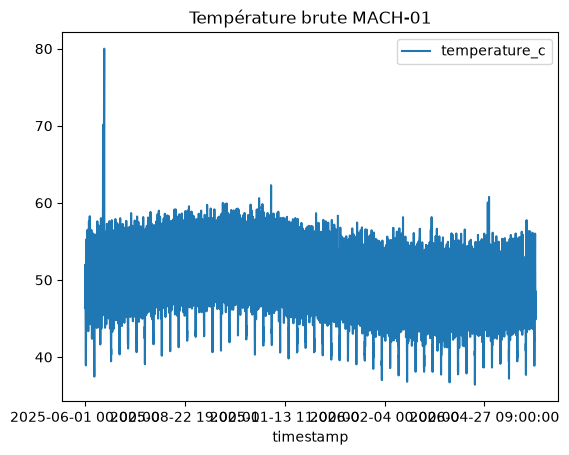

In [22]:
import matplotlib.pyplot as plt
bronze = datas

# Série temporelle brute d'une machine
m1 = bronze[bronze["machine_id"] == "MACH-01"]
m1.plot(x="timestamp", y="temperature_c", title="Température brute MACH-01")

run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "temperature_mach01.png", bbox_inches="tight")
plt.show()

## Analyse de la distribution du df bronze

Répertoire créé : artifacts\ingestions\incidents\202606220836


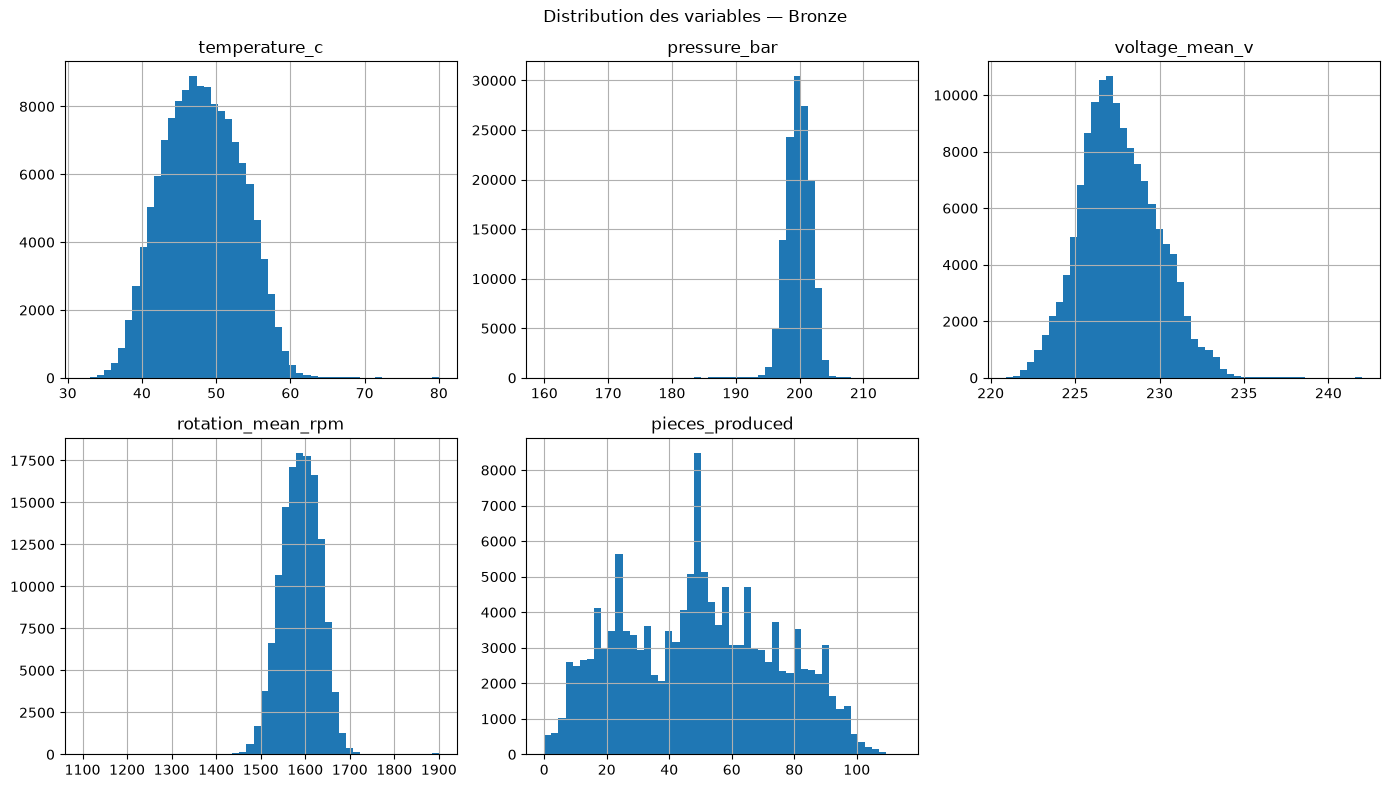

In [23]:
import matplotlib.pyplot as plt

numeric_cols = ["temperature_c", "pressure_bar", "voltage_mean_v", "rotation_mean_rpm", "pieces_produced"]

bronze[numeric_cols].hist(bins=50, figsize=(14, 8), layout=(2, 3))
plt.suptitle("Distribution des variables — Bronze")
plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "Distribution des variables — Bronze.png", bbox_inches="tight")
plt.show()

## Boxplots par machine (pour détecter les outliers visuellement)

Répertoire créé : artifacts\ingestions\incidents\202606220836


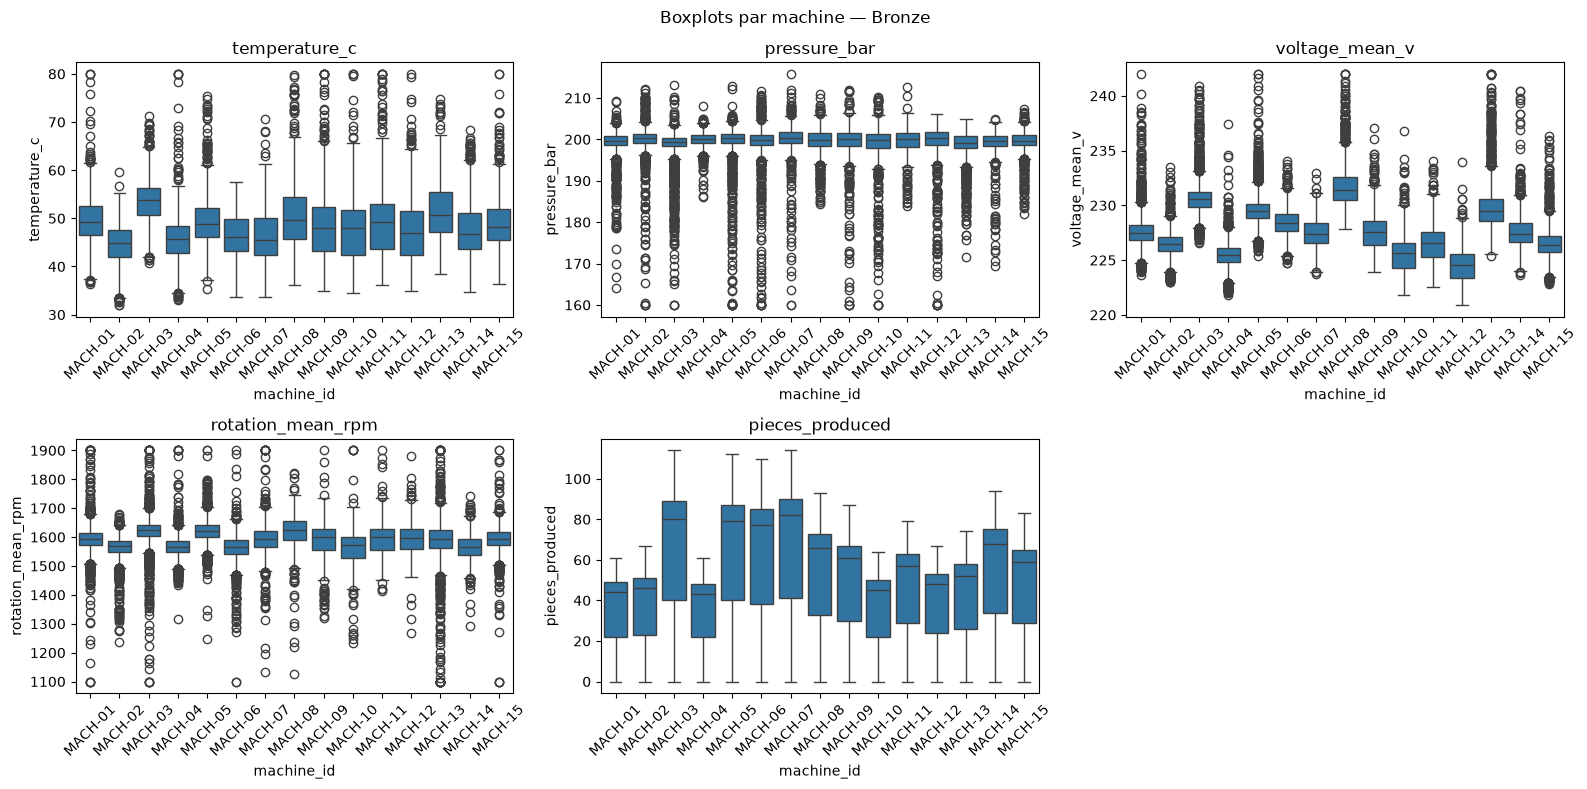

In [24]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=bronze, x="machine_id", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].set_visible(False)
plt.suptitle("Boxplots par machine — Bronze")
plt.tight_layout()

run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "Boxplots par machine — Bronze.png", bbox_inches="tight")
plt.show()

## Détecter visuellement les outliers (IQR)

In [25]:
for col in numeric_cols:
    Q1  = bronze[col].quantile(0.25)
    Q3  = bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    n = ((bronze[col] < low) | (bronze[col] > high)).sum()
    print(f"{col:25s} → {n} outliers  (bornes : [{low:.1f}, {high:.1f}])")

temperature_c             → 52 outliers  (bornes : [20.8, 75.5])
pressure_bar              → 769 outliers  (bornes : [190.7, 209.0])
voltage_mean_v            → 77 outliers  (bornes : [216.7, 238.5])
rotation_mean_rpm         → 303 outliers  (bornes : [1373.5, 1806.3])
pieces_produced           → 0 outliers  (bornes : [-92.0, 188.0])


## Croisement outliers × incidents — les outliers sont-ils des signaux de panne ?

Lignes avec au moins 1 outlier capteur : 1139 / 135626 (0.84 %)

Outliers associés à un incident (±24h) : 1079 / 1139 (94.7 %)

3. CAPTEUR OUTLIER × TYPE D'INCIDENT (% des outliers appariés)
                   type_surchauffe  type_baisse_pression  type_vibration  type_bruit_mecanique  type_surconsommation  type_blocage_mecanique  type_alarme_capteur  type_arret_urgence  type_defaut_qualite
capteur                                                                                                                                                                                                   
temperature_c                100.0                   0.0             0.0                   0.0                   0.0                     0.0                  0.0                 0.0                  0.0
pressure_bar                   5.0                  75.9             2.1                   1.8                   5.3                     2.8                  3.2                 1.5                  2

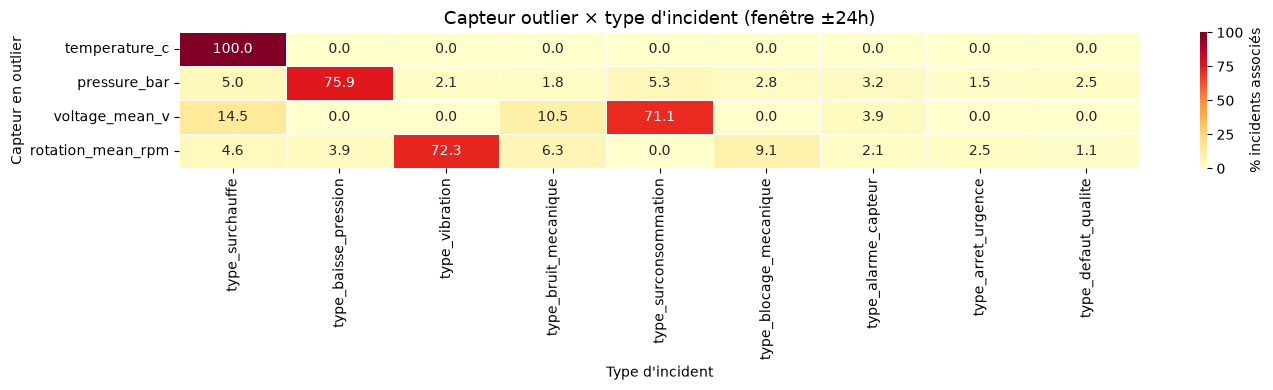


4. SÉVÉRITÉ DES INCIDENTS ASSOCIÉS AUX OUTLIERS
Sévérité moyenne : 2.87
severity
2    201
3    834
4     30
5     14

5. CONCLUSION — FAUT-IL CONSERVER LES OUTLIERS POUR L'ENTRAÎNEMENT ?

94.7 % des outliers capteurs sont associés à un incident réel (±24h).

Si ce taux est élevé (> 30-40 %) :
  → Les outliers NE sont PAS du bruit aléatoire.
  → Ils constituent un signal prédictif de panne.
  → Les supprimer avant l'entraînement détruirait de l'information utile.
  → Stratégie recommandée : conserver les valeurs brutes en feature,
    ajouter un flag booléen (is_outlier_temp_c, etc.) plutôt que de
    remplacer les outliers par interpolation dans le dataset ML.

Si ce taux est faible (< 10 %) :
  → Les outliers sont probablement des erreurs de capteur (bruit).
  → L'interpolation actuelle est justifiée pour le silver.
  → En ML, utiliser le silver (données nettoyées).



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Chargement ─────────────────────────────────────────────────────────────────
tel = pd.read_csv("telemetry.csv", parse_dates=["timestamp"])
inc = pd.read_csv("releves_incidents.csv")

inc["datetime"] = pd.to_datetime(inc["date"] + " " + inc["time"])
inc = inc.sort_values("datetime").reset_index(drop=True)

INCIDENT_TYPES = [
    "type_surchauffe", "type_baisse_pression", "type_vibration",
    "type_bruit_mecanique", "type_surconsommation", "type_blocage_mecanique",
    "type_alarme_capteur", "type_arret_urgence", "type_defaut_qualite",
]

# ── 1. Flaguer les outliers IQR dans la télémétrie ────────────────────────────
SENSOR_COLS = ["temperature_c", "pressure_bar", "voltage_mean_v", "rotation_mean_rpm"]
IQR_FACTOR  = 3

tel_flagged = tel.copy()
for col in SENSOR_COLS:
    Q1, Q3 = tel[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    tel_flagged[f"outlier_{col}"] = (
        (tel[col] < Q1 - IQR_FACTOR * IQR) | (tel[col] > Q3 + IQR_FACTOR * IQR)
    )

tel_flagged["any_outlier"] = tel_flagged[[f"outlier_{c}" for c in SENSOR_COLS]].any(axis=1)
outlier_rows = tel_flagged[tel_flagged["any_outlier"]].copy()

print(f"Lignes avec au moins 1 outlier capteur : {len(outlier_rows)} / {len(tel)} ({len(outlier_rows)/len(tel)*100:.2f} %)")

# ── 2. Pour chaque outlier, chercher un incident sur la même machine ──────────
# Fenêtre de recherche : ±24h autour de la mesure outlier
WINDOW_H = 24

def has_incident_nearby(machine, ts, inc_df, window_h=WINDOW_H):
    mask = (
        (inc_df["machine_id"] == machine) &
        (inc_df["datetime"] >= ts - pd.Timedelta(hours=window_h)) &
        (inc_df["datetime"] <= ts + pd.Timedelta(hours=window_h))
    )
    return inc_df[mask]

records = []
for _, row in outlier_rows.iterrows():
    nearby = has_incident_nearby(row["machine_id"], row["timestamp"], inc)
    if not nearby.empty:
        for _, inc_row in nearby.iterrows():
            records.append({
                "machine_id"    : row["machine_id"],
                "timestamp"     : row["timestamp"],
                **{f"outlier_{c}": row[f"outlier_{c}"] for c in SENSOR_COLS},
                "incident_dt"   : inc_row["datetime"],
                "severity"      : inc_row["severity"],
                **{t: inc_row[t] for t in INCIDENT_TYPES},
            })

matched = pd.DataFrame(records).drop_duplicates(subset=["machine_id", "timestamp"])

print(f"\nOutliers associés à un incident (±{WINDOW_H}h) : {len(matched)} / {len(outlier_rows)} "
      f"({len(matched)/len(outlier_rows)*100:.1f} %)")

# ── 3. Heatmap capteur outlier × type d'incident ──────────────────────────────
print("\n" + "=" * 65)
print(f"3. CAPTEUR OUTLIER × TYPE D'INCIDENT (% des outliers appariés)")
print("=" * 65)

if not matched.empty:
    rows_heatmap = []
    for col in SENSOR_COLS:
        col_flag = f"outlier_{col}"
        sub = matched[matched[col_flag] == True]
        total = sub.shape[0]
        if total == 0:
            continue
        row_data = {"capteur": col}
        for inc_type in INCIDENT_TYPES:
            row_data[inc_type] = round(sub[inc_type].sum() / total * 100, 1)
        rows_heatmap.append(row_data)

    heatmap_df = pd.DataFrame(rows_heatmap).set_index("capteur")
    print(heatmap_df.to_string())

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd",
        linewidths=0.5, ax=ax, cbar_kws={"label": "% incidents associés"}
    )
    ax.set_title(f"Capteur outlier × type d'incident (fenêtre ±{WINDOW_H}h)", fontsize=13)
    ax.set_xlabel("Type d'incident")
    ax.set_ylabel("Capteur en outlier")
    plt.tight_layout()
    plt.show()
else:
    print("Aucun outlier apparié — vérifier les dates communes entre les deux fichiers.")

# ── 4. Sévérité des incidents associés ────────────────────────────────────────
print("\n" + "=" * 65)
print("4. SÉVÉRITÉ DES INCIDENTS ASSOCIÉS AUX OUTLIERS")
print("=" * 65)
if not matched.empty:
    print(f"Sévérité moyenne : {matched['severity'].mean():.2f}")
    print(matched["severity"].value_counts().sort_index().to_string())

# ── 5. Conclusion ──────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("5. CONCLUSION — FAUT-IL CONSERVER LES OUTLIERS POUR L'ENTRAÎNEMENT ?")
print("=" * 65)
pct = len(matched) / len(outlier_rows) * 100 if len(outlier_rows) > 0 else 0
print(f"""
{pct:.1f} % des outliers capteurs sont associés à un incident réel (±{WINDOW_H}h).

Si ce taux est élevé (> 30-40 %) :
  → Les outliers NE sont PAS du bruit aléatoire.
  → Ils constituent un signal prédictif de panne.
  → Les supprimer avant l'entraînement détruirait de l'information utile.
  → Stratégie recommandée : conserver les valeurs brutes en feature,
    ajouter un flag booléen (is_outlier_temp_c, etc.) plutôt que de
    remplacer les outliers par interpolation dans le dataset ML.

Si ce taux est faible (< 10 %) :
  → Les outliers sont probablement des erreurs de capteur (bruit).
  → L'interpolation actuelle est justifiée pour le silver.
  → En ML, utiliser le silver (données nettoyées).
""")

## Production du silver 

In [27]:
import numpy as np

# ── Paramètres ─────────────────────────────────────────────────────────────
INPUT_PATH  = "telemetry.csv"
OUTPUT_PATH = "telemetry_silver.csv"

NUMERIC_COLS = [
    "temperature_c",
    "pressure_bar",
    "voltage_mean_v",
    "rotation_mean_rpm",
]

IQR_FACTOR = 3  # seuil outlier : Q1 - 3*IQR  /  Q3 + 3*IQR

# ── 1. Chargement ──────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)

# ── 2. Typage ──────────────────────────────────────────────────────────────
df["timestamp"]  = pd.to_datetime(df["timestamp"])
df["machine_id"] = df["machine_id"].astype("category")

# ── 3. Tri chronologique ───────────────────────────────────────────────────
df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

# ── 4. Colonnes temporelles ────────────────────────────────────────────────
df["year"]        = df["timestamp"].dt.year
df["month"]       = df["timestamp"].dt.month
df["day"]         = df["timestamp"].dt.day
df["hour"]        = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0 = lundi
df["is_weekend"]  = df["day_of_week"].isin([5, 6])

# ── 5. Flag arrêt machine ──────────────────────────────────────────────────
df["is_stopped"] = df["pieces_produced"] == 0

# ── 6. Détection outliers → NaN → interpolation par machine ───────────────
outlier_report = {}

for col in NUMERIC_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - IQR_FACTOR * IQR
    high = Q3 + IQR_FACTOR * IQR

    mask = (df[col] < low) | (df[col] > high)
    outlier_report[col] = int(mask.sum())
    df.loc[mask, col] = np.nan

# Interpolation linéaire par machine (comble les NaN créés ci-dessus)
df[NUMERIC_COLS] = (
    df.groupby("machine_id", observed=True)[NUMERIC_COLS]
      .transform(lambda g: g.interpolate(method="linear", limit_direction="both"))
)

# ── 7. Arrondi ─────────────────────────────────────────────────────────────
df[NUMERIC_COLS] = df[NUMERIC_COLS].round(2)

# ── 8. Renommage ───────────────────────────────────────────────────────────
df = df.rename(columns={
    "temperature_c":    "temp_c",
    "voltage_mean_v":   "voltage_v",
    "rotation_mean_rpm":"rotation_rpm",
})

# ── 9. Ordre des colonnes ──────────────────────────────────────────────────
cols = [
    "machine_id", "timestamp",
    "year", "month", "day", "hour", "day_of_week", "is_weekend",
    "temp_c", "pressure_bar", "voltage_v", "rotation_rpm",
    "pieces_produced", "is_stopped",
]
df = df[cols]

# ── 10. Export ─────────────────────────────────────────────────────────────
#df.to_csv(OUTPUT_PATH, index=False)
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
df.to_csv(run_dir / OUTPUT_PATH, index=False)

# ── Rapport ────────────────────────────────────────────────────────────────
print(f"Shape          : {df.shape}")
print(f"NaN restants   : {df.isna().sum().sum()}")
print(f"Machines       : {df['machine_id'].nunique()}")
print(f"Période        : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Arrêts détectés: {df['is_stopped'].sum()}")
print()
print("Outliers traités :")
for col, n in outlier_report.items():
    print(f"  {col}: {n}")
print()
print(f"Fichier exporté : {OUTPUT_PATH}")

Répertoire créé : artifacts\ingestions\incidents\202606220836
Shape          : (135626, 14)
NaN restants   : 0
Machines       : 15
Période        : 2025-06-01 00:00:00 → 2026-06-08 23:00:00
Arrêts détectés: 271

Outliers traités :
  temperature_c: 52
  pressure_bar: 769
  voltage_mean_v: 77
  rotation_mean_rpm: 303

Fichier exporté : telemetry_silver.csv


## détection visuelle des outliers (IQR) — comparaison avant/après (bronze/silver)

In [28]:

# Détection des outliers IQR sur le silver — comparaison avant/après
print("=" * 60)
print("COMPARAISON OUTLIERS : BRONZE vs SILVER")
print("=" * 60)
print()

# Colonnes à vérifier (avec noms silver)
silver_cols = ["temp_c", "pressure_bar", "voltage_v", "rotation_rpm"]

print("BRONZE (avant traitement) :")
print("-" * 60)
bronze_outliers = {}
for col in numeric_cols[:4]:  # Les 4 premières colonnes numériques
    Q1  = bronze[col].quantile(0.25)
    Q3  = bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    n = ((bronze[col] < low) | (bronze[col] > high)).sum()
    bronze_outliers[col] = n
    print(f"{col:25s} → {n:4d} outliers")

print()
print("SILVER (après interpolation) :")
print("-" * 60)
silver_outliers = {}
for col in silver_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    n = ((df[col] < low) | (df[col] > high)).sum()
    silver_outliers[col] = n
    print(f"{col:25s} → {n:4d} outliers")

print()
print("RÉSUMÉ :")
print("-" * 60)
total_bronze = sum(bronze_outliers.values())
total_silver = sum(silver_outliers.values())
print(f"Total outliers BRONZE  : {total_bronze}")
print(f"Total outliers SILVER  : {total_silver}")
print(f"Réduction             : {total_bronze - total_silver} outliers supprimés")
print()


COMPARAISON OUTLIERS : BRONZE vs SILVER

BRONZE (avant traitement) :
------------------------------------------------------------
temperature_c             →   52 outliers
pressure_bar              →  769 outliers
voltage_mean_v            →   77 outliers
rotation_mean_rpm         →  303 outliers

SILVER (après interpolation) :
------------------------------------------------------------
temp_c                    →    1 outliers
pressure_bar              →    9 outliers
voltage_v                 →    0 outliers
rotation_rpm              →    1 outliers

RÉSUMÉ :
------------------------------------------------------------
Total outliers BRONZE  : 1201
Total outliers SILVER  : 11
Réduction             : 1190 outliers supprimés



## Analyse des Séries Temporelles

Répertoire créé : artifacts\ingestions\incidents\202606220836


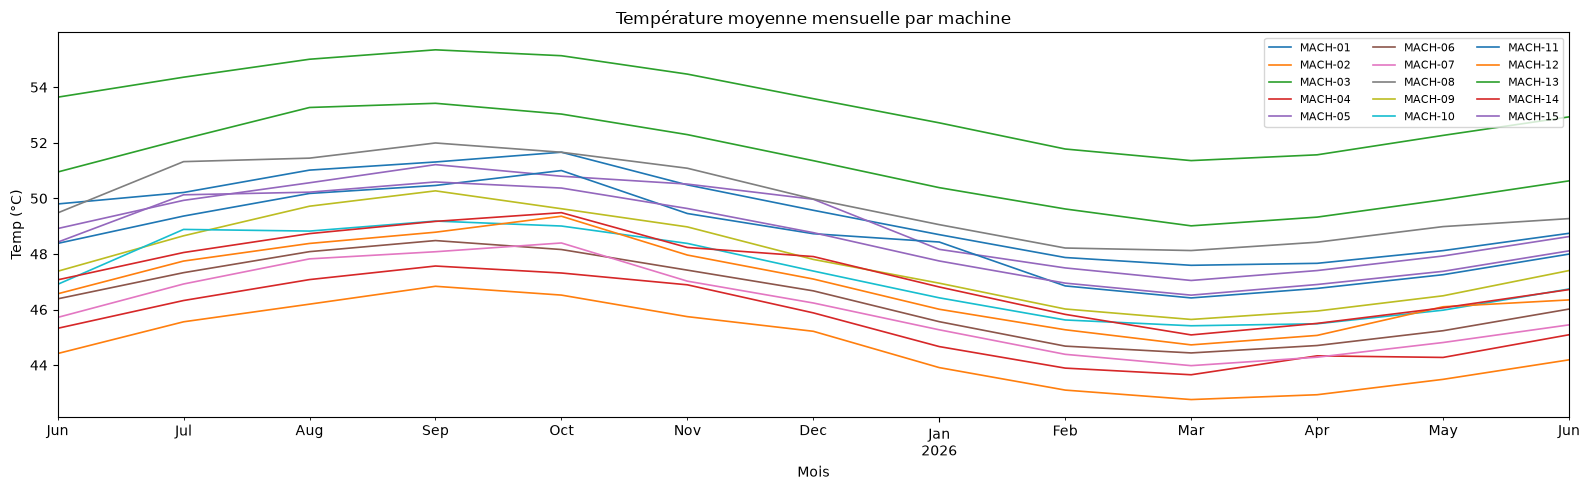

In [29]:
# ── 1. Tendance mensuelle par machine ──────────────────────────────────────
monthly = (
    df.groupby(["machine_id", pd.Grouper(key="timestamp", freq="ME")])["temp_c"]
    .mean()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(16, 5))
monthly.plot(ax=ax, linewidth=1.2)
ax.set_title("Température moyenne mensuelle par machine")
ax.set_xlabel("Mois")
ax.set_ylabel("Temp (°C)")
ax.legend(loc="upper right", ncol=3, fontsize=8)
plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "tendance_mensuelle_temp.png", bbox_inches="tight")
plt.show()

Répertoire créé : artifacts\ingestions\incidents\202606220836


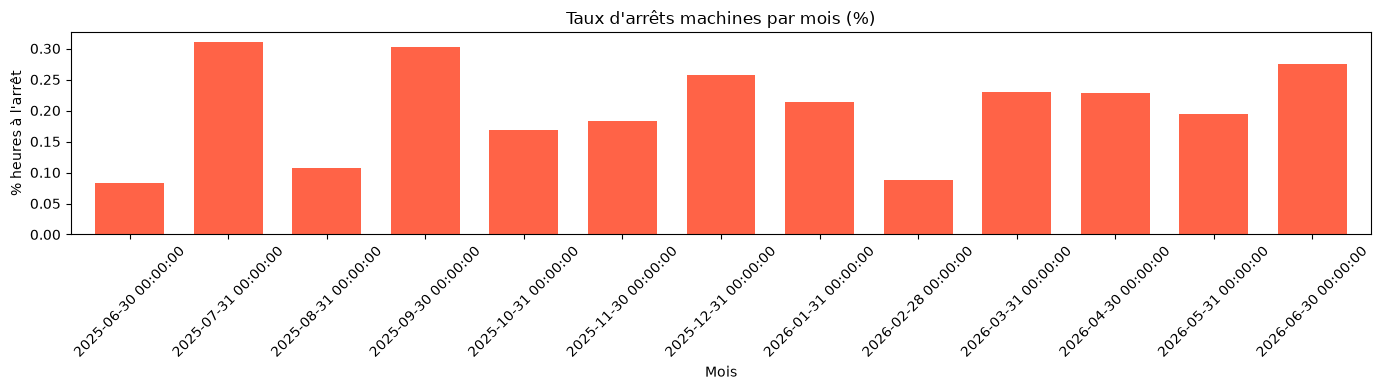

In [30]:
# ── 2. Taux d'arrêts par mois ──────────────────────────────────────────────
stop_rate = (
    df.groupby(pd.Grouper(key="timestamp", freq="ME"))["is_stopped"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(14, 4))
stop_rate.plot(kind="bar", ax=ax, color="tomato", width=0.7)
ax.set_title("Taux d'arrêts machines par mois (%)")
ax.set_xlabel("Mois")
ax.set_ylabel("% heures à l'arrêt")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "taux_arrets_mensuel.png", bbox_inches="tight")
plt.show()

Répertoire créé : artifacts\ingestions\incidents\202606220836


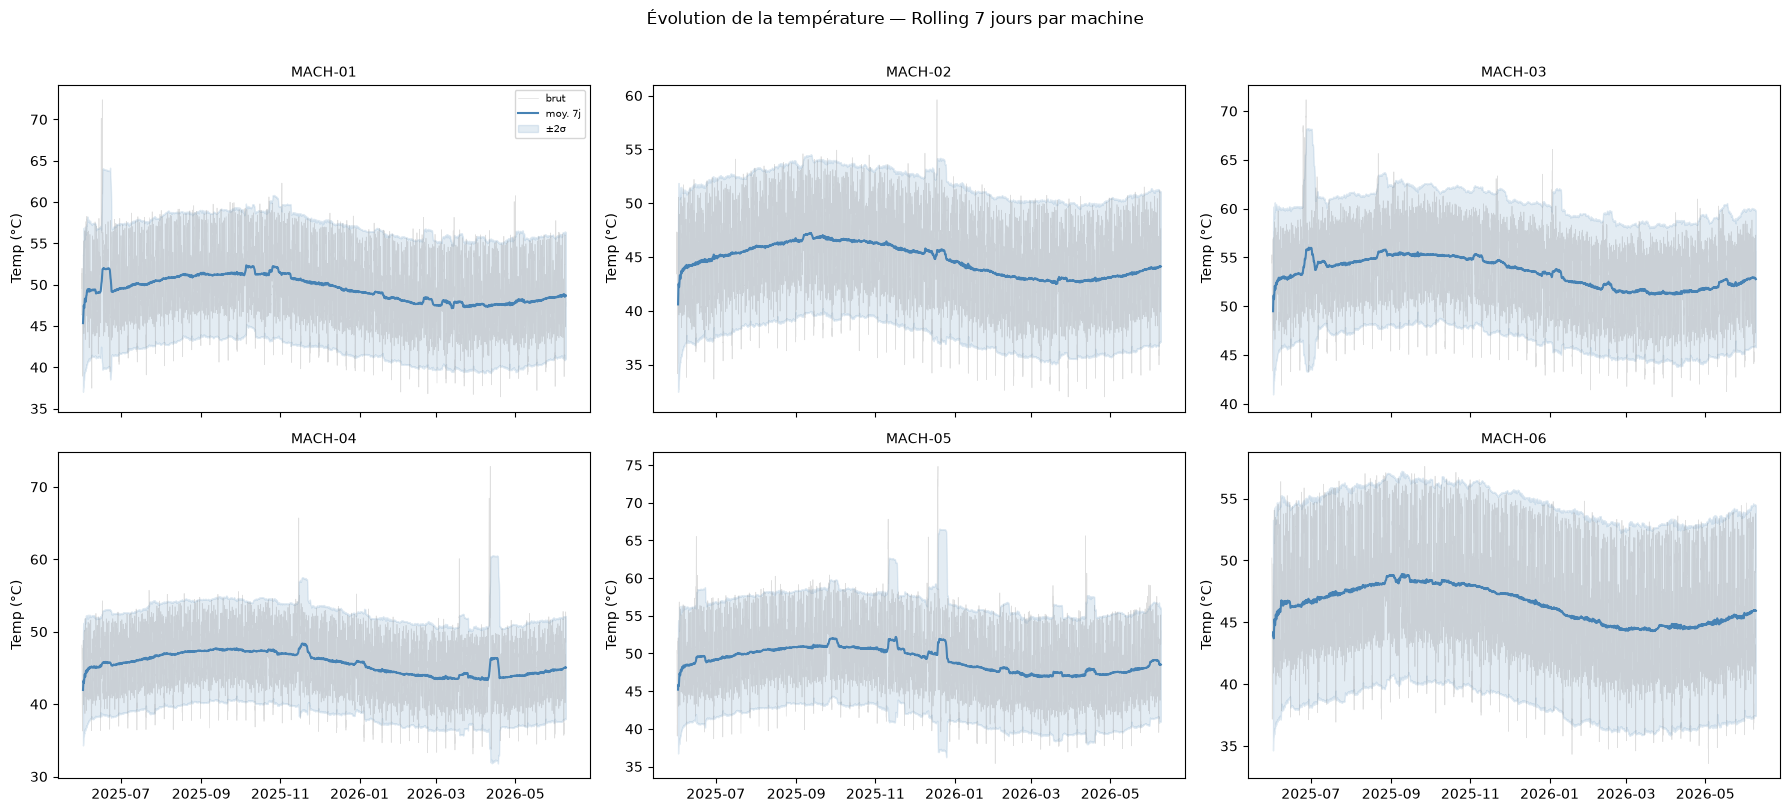

In [31]:
# ── 3. Rolling 7 jours — détection de dégradation progressive ─────────────
# Fenêtre de 168h = 7 jours de mesures horaires
machines_to_plot = df["machine_id"].unique()[:6]  # 6 premières machines

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, machine in enumerate(machines_to_plot):
    subset = df[df["machine_id"] == machine].set_index("timestamp")
    rolling_mean = subset["temp_c"].rolling(window=168, min_periods=24).mean()
    rolling_std  = subset["temp_c"].rolling(window=168, min_periods=24).std()

    ax = axes[i]
    ax.plot(subset.index, subset["temp_c"], alpha=0.25, linewidth=0.5, color="gray", label="brut")
    ax.plot(rolling_mean.index, rolling_mean, linewidth=1.5, color="steelblue", label="moy. 7j")
    ax.fill_between(
        rolling_mean.index,
        rolling_mean - 2 * rolling_std,
        rolling_mean + 2 * rolling_std,
        alpha=0.15, color="steelblue", label="±2σ"
    )
    ax.set_title(machine, fontsize=10)
    ax.set_ylabel("Temp (°C)")
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Évolution de la température — Rolling 7 jours par machine", y=1.01)
plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "rolling_7j_temperature.png", bbox_inches="tight")
plt.show()

Répertoire créé : artifacts\ingestions\incidents\202606220836


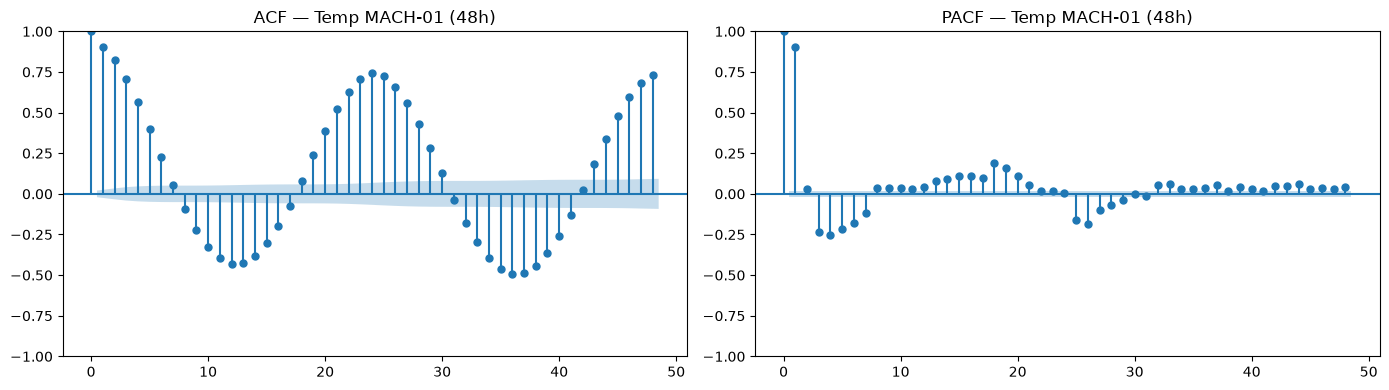

Pic à lag=24 → saisonnalité journalière (cycle de 24h)
Décroissance lente de l'ACF → la série a une tendance ou une mémoire longue


In [32]:
# ── 4. Autocorrélation — mémoire de la série température (MACH-01) ─────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

mach01 = df[df["machine_id"] == "MACH-01"].set_index("timestamp")["temp_c"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(mach01, lags=48, ax=axes[0], title="ACF — Temp MACH-01 (48h)")
plot_pacf(mach01, lags=48, ax=axes[1], title="PACF — Temp MACH-01 (48h)")
plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "acf_pacf_temp_mach01.png", bbox_inches="tight")
plt.show()

print("Pic à lag=24 → saisonnalité journalière (cycle de 24h)")
print("Décroissance lente de l'ACF → la série a une tendance ou une mémoire longue")